# `rag-stress` — Qwen3-4B Statistical Analysis with Counterfactual V2

This notebook performs the final within-model analysis for:

```text
Qwen/Qwen3-4B-Instruct-2507
```

It reads the previously evaluated **clean, distractor, and position** results from Google Drive, while replacing the old counterfactual experiment with the new **strict semantic Counterfactual V2** results.

### Inputs

```text
/content/drive/MyDrive/rag_stress/evaluation/
├── clean_evaluated.jsonl
├── distractor_evaluated.jsonl
└── position_evaluated.jsonl
```

and:

```text
/content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/
└── counterfactual_v2_evaluated.jsonl
```

### Outputs

All analysis artifacts are saved to:

```text
/content/drive/MyDrive/rag_stress/analysis_qwen3_4b_counterfactual_v2/
```

The analysis includes:

- paired bootstrap confidence intervals
- McNemar tests for Exact Match
- Wilcoxon signed-rank tests for per-example F1
- Clean → D1/D3/D5 transition analysis
- robustness trajectory classes
- position-bias trajectories
- strict lost-in-the-middle cases
- Counterfactual V2 CFR / GFR / OTHER
- V2 analysis by semantic type
- V2 analysis by replacement source
- representative qualitative examples
- publication-ready CSVs, JSON summary, and figures


In [1]:
from pathlib import Path
import json
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, binomtest
from google.colab import drive

# ---------------------------------------------------------
# Mount Google Drive
# ---------------------------------------------------------
drive.mount("/content/drive")

# ---------------------------------------------------------
# Model / experiment identity
# ---------------------------------------------------------
MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
ANALYSIS_VERSION = "counterfactual_v2"

# ---------------------------------------------------------
# Google Drive paths
# ---------------------------------------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive/rag_stress")

# Previous evaluated results for the same Qwen3-4B model
BASE_EVAL_DIR = DRIVE_ROOT / "evaluation"

CLEAN_FILE = BASE_EVAL_DIR / "clean_evaluated.jsonl"
DISTRACTOR_FILE = BASE_EVAL_DIR / "distractor_evaluated.jsonl"
POSITION_FILE = BASE_EVAL_DIR / "position_evaluated.jsonl"

# New strict semantic counterfactual V2 evaluation
CF_V2_EVAL_DIR = DRIVE_ROOT / "counterfactual_v2" / "evaluation"
COUNTERFACTUAL_FILE = CF_V2_EVAL_DIR / "counterfactual_v2_evaluated.jsonl"

# Final analysis outputs
OUT_DIR = DRIVE_ROOT / "analysis_qwen3_4b_counterfactual_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
N_BOOTSTRAP = 10000

rng = np.random.default_rng(SEED)

print("Model:", MODEL_NAME)
print("Base evaluation dir:", BASE_EVAL_DIR)
print("Counterfactual V2 dir:", CF_V2_EVAL_DIR)
print("Analysis output dir:", OUT_DIR)


Mounted at /content/drive
Model: Qwen/Qwen3-4B-Instruct-2507
Base evaluation dir: /content/drive/MyDrive/rag_stress/evaluation
Counterfactual V2 dir: /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation
Analysis output dir: /content/drive/MyDrive/rag_stress/analysis_qwen3_4b_counterfactual_v2


## 1. Load evaluated results

In [2]:
def load_jsonl(path):
    with path.open("r", encoding="utf-8") as f:
        return [
            json.loads(line)
            for line in f
            if line.strip()
        ]


input_files = {
    "clean": CLEAN_FILE,
    "distractor": DISTRACTOR_FILE,
    "position": POSITION_FILE,
    "counterfactual_v2": COUNTERFACTUAL_FILE,
}

print("Input files:\n")

for name, path in input_files.items():
    print(
        f"{name:20s}",
        "FOUND" if path.exists() else "MISSING",
        "->",
        path
    )

missing = [
    str(path)
    for path in input_files.values()
    if not path.exists()
]

assert not missing, (
    "Missing evaluated file(s):\n"
    + "\n".join(missing)
)

clean = load_jsonl(CLEAN_FILE)
distractor = load_jsonl(DISTRACTOR_FILE)
position = load_jsonl(POSITION_FILE)
counterfactual = load_jsonl(COUNTERFACTUAL_FILE)

print("\nRows:")
print("Clean:", len(clean))
print("Distractor:", len(distractor))
print("Position:", len(position))
print("Counterfactual V2:", len(counterfactual))

print("\nExpected structure:")
print("Clean should be ~500")
print("Distractor should be ~1500")
print("Position should be ~1500")
print("Counterfactual V2 should match the strict V2 dataset size")


Input files:

clean                FOUND -> /content/drive/MyDrive/rag_stress/evaluation/clean_evaluated.jsonl
distractor           FOUND -> /content/drive/MyDrive/rag_stress/evaluation/distractor_evaluated.jsonl
position             FOUND -> /content/drive/MyDrive/rag_stress/evaluation/position_evaluated.jsonl
counterfactual_v2    FOUND -> /content/drive/MyDrive/rag_stress/counterfactual_v2/evaluation/counterfactual_v2_evaluated.jsonl

Rows:
Clean: 500
Distractor: 1500
Position: 1500
Counterfactual V2: 232

Expected structure:
Clean should be ~500
Distractor should be ~1500
Position should be ~1500
Counterfactual V2 should match the strict V2 dataset size


## 1B. Verify model and V2 provenance

In [6]:
# Verify that the loaded rows are compatible with the intended experiment.

def unique_non_null(records, key):
    return sorted({
        str(r[key])
        for r in records
        if key in r and r[key] is not None
    })


print("Clean models:", unique_non_null(clean, "model"))
print("Distractor models:", unique_non_null(distractor, "model"))
print("Position models:", unique_non_null(position, "model"))
print("Counterfactual V2 models:", unique_non_null(counterfactual, "model"))

print("\nCounterfactual V2 classes:")
print(
    Counter(
        r.get("cf_class", "MISSING")
        for r in counterfactual
    )
)

required_cf_fields = {
    "id",
    "gold_answer",
    "counterfactual_answer",
    "model_answer",
    "cf_class",
}

bad_cf_rows = [
    r.get("id")
    for r in counterfactual
    if not required_cf_fields.issubset(r.keys())
]

assert not bad_cf_rows, (
    "Counterfactual V2 rows missing required fields: "
    + str(bad_cf_rows[:10])
)

print("\nInput provenance/fields look usable.")


Clean models: ['Qwen/Qwen3-4B-Instruct-2507']
Distractor models: ['Qwen/Qwen3-4B-Instruct-2507']
Position models: ['Qwen/Qwen3-4B-Instruct-2507']
Counterfactual V2 models: ['Qwen/Qwen3-4B-Instruct-2507']

Counterfactual V2 classes:
Counter({'OTHER': 112, 'COUNTERFACTUAL_FOLLOW': 112, 'GOLD_FOLLOW': 8})

Input provenance/fields look usable.


## 2. Convert to DataFrames

In [7]:
clean_df = pd.DataFrame(clean)
distractor_df = pd.DataFrame(distractor)
position_df = pd.DataFrame(position)
cf_df = pd.DataFrame(counterfactual)

display(clean_df.head(2))


,id,experiment,condition,question,gold_answer,model_answer,raw_model_output,model,temperature,max_new_tokens,seed,em,f1
0,5adf4b335542993a75d264a5,clean,clean,Paul DeBoy is known for an appearance in the W...,Rockstar San Diego,Rockstar Games,Rockstar Games,Qwen/Qwen3-4B-Instruct-2507,0.0,32,42,0,0.4
1,5adbcd475542996e68525240,clean,clean,In what year did the manager of the singer-son...,2005,2005,2005,Qwen/Qwen3-4B-Instruct-2507,0.0,32,42,1,1.0


## 3. Build paired matrices by question ID

In [8]:
clean_small = clean_df[
    ["id", "question", "gold_answer", "model_answer", "em", "f1"]
].copy()

clean_small = clean_small.rename(columns={
    "model_answer": "clean_answer",
    "em": "clean_em",
    "f1": "clean_f1",
})

dist_wide = distractor_df.pivot(
    index="id",
    columns="condition",
    values=["model_answer", "em", "f1"]
)

dist_wide.columns = [
    f"{metric}_{cond}"
    for metric, cond in dist_wide.columns
]

dist_wide = dist_wide.reset_index()

paired_dist = clean_small.merge(
    dist_wide,
    on="id",
    how="inner"
)

print("Paired clean/distractor questions:", len(paired_dist))
display(paired_dist.head(2))


Paired clean/distractor questions: 500


,id,question,gold_answer,clean_answer,clean_em,clean_f1,model_answer_D1,model_answer_D3,model_answer_D5,em_D1,em_D3,em_D5,f1_D1,f1_D3,f1_D5
0,5adf4b335542993a75d264a5,Paul DeBoy is known for an appearance in the W...,Rockstar San Diego,Rockstar Games,0,0.4,Rockstar Games,Rockstar Games,Rockstar Games,0,0,0,0.4,0.4,0.4
1,5adbcd475542996e68525240,In what year did the manager of the singer-son...,2005,2005,1,1.0,2005,2005,2005,1,1,1,1.0,1.0,1.0


## 4. Position paired matrix

In [9]:
pos_wide = position_df.pivot(
    index="id",
    columns="condition",
    values=["model_answer", "em", "f1"]
)

pos_wide.columns = [
    f"{metric}_{cond}"
    for metric, cond in pos_wide.columns
]

pos_wide = pos_wide.reset_index()

print("Paired position questions:", len(pos_wide))
display(pos_wide.head(2))


Paired position questions: 500


,id,model_answer_beginning,model_answer_end,model_answer_middle,em_beginning,em_end,em_middle,f1_beginning,f1_end,f1_middle
0,5a70eee85542994082a3e3f0,Yoruba people,Yoruba people,Yoruba people,0,0,0,0.666667,0.666667,0.666667
1,5a70ff335542994082a3e49c,Kareena Kapoor,Kareena Kapoor,Kareena Kapoor,0,0,0,0.8,0.8,0.8


## 5. Paired bootstrap confidence intervals

We bootstrap over **question IDs**, preserving the pairing across conditions.

This is preferable to independently resampling each condition because each condition is evaluated on the same questions.


In [10]:
def paired_bootstrap_difference(
    a,
    b,
    n_bootstrap=N_BOOTSTRAP,
    seed=SEED,
):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    assert len(a) == len(b)

    rng_local = np.random.default_rng(seed)
    n = len(a)

    observed = float(np.mean(a - b))

    samples = np.empty(n_bootstrap, dtype=float)

    for i in range(n_bootstrap):
        idx = rng_local.integers(0, n, size=n)
        samples[i] = np.mean(a[idx] - b[idx])

    lo, hi = np.percentile(samples, [2.5, 97.5])

    return {
        "difference": observed,
        "ci_low": float(lo),
        "ci_high": float(hi),
    }


## 6. McNemar test for paired Exact Match

In [11]:
def mcnemar_exact(a, b):
    """
    Exact McNemar test using the binomial form.

    b01 = A correct, B wrong
    b10 = A wrong, B correct
    """
    a = np.asarray(a, dtype=int)
    b = np.asarray(b, dtype=int)

    b01 = int(np.sum((a == 1) & (b == 0)))
    b10 = int(np.sum((a == 0) & (b == 1)))

    discordant = b01 + b10

    if discordant == 0:
        p_value = 1.0
    else:
        p_value = binomtest(
            min(b01, b10),
            n=discordant,
            p=0.5,
            alternative="two-sided",
        ).pvalue

    return {
        "a_correct_b_wrong": b01,
        "a_wrong_b_correct": b10,
        "discordant": discordant,
        "p_value": float(p_value),
    }


## 7. Wilcoxon signed-rank for per-example F1

In [12]:
def wilcoxon_f1(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    diff = a - b

    if np.allclose(diff, 0):
        return {
            "statistic": 0.0,
            "p_value": 1.0,
        }

    result = wilcoxon(
        a,
        b,
        zero_method="wilcox",
        alternative="two-sided",
    )

    return {
        "statistic": float(result.statistic),
        "p_value": float(result.pvalue),
    }


## 8. Statistical tests: Clean vs D1 / D3 / D5


In [13]:
dist_stats = []

for cond in ["D1", "D3", "D5"]:
    em_boot = paired_bootstrap_difference(
        paired_dist["clean_em"],
        paired_dist[f"em_{cond}"],
    )

    f1_boot = paired_bootstrap_difference(
        paired_dist["clean_f1"],
        paired_dist[f"f1_{cond}"],
    )

    mc = mcnemar_exact(
        paired_dist["clean_em"],
        paired_dist[f"em_{cond}"],
    )

    w = wilcoxon_f1(
        paired_dist["clean_f1"],
        paired_dist[f"f1_{cond}"],
    )

    dist_stats.append({
        "comparison": f"clean_vs_{cond}",
        "n": len(paired_dist),

        "clean_em": paired_dist["clean_em"].mean(),
        f"{cond}_em": paired_dist[f"em_{cond}"].mean(),

        "em_difference_clean_minus_condition":
            em_boot["difference"],
        "em_ci_low": em_boot["ci_low"],
        "em_ci_high": em_boot["ci_high"],

        "mcnemar_clean_correct_condition_wrong":
            mc["a_correct_b_wrong"],
        "mcnemar_clean_wrong_condition_correct":
            mc["a_wrong_b_correct"],
        "mcnemar_p": mc["p_value"],

        "clean_f1": paired_dist["clean_f1"].mean(),
        f"{cond}_f1": paired_dist[f"f1_{cond}"].mean(),

        "f1_difference_clean_minus_condition":
            f1_boot["difference"],
        "f1_ci_low": f1_boot["ci_low"],
        "f1_ci_high": f1_boot["ci_high"],

        "wilcoxon_f1_p": w["p_value"],
    })

dist_stats_df = pd.DataFrame(dist_stats)
display(dist_stats_df.round(5))


,comparison,n,clean_em,D1_em,em_difference_clean_minus_condition,em_ci_low,em_ci_high,mcnemar_clean_correct_condition_wrong,mcnemar_clean_wrong_condition_correct,mcnemar_p,clean_f1,D1_f1,f1_difference_clean_minus_condition,f1_ci_low,f1_ci_high,wilcoxon_f1_p,D3_em,D3_f1,D5_em,D5_f1
0,clean_vs_D1,500,0.492,0.462,0.030,0.008,0.052,23,8,0.01067,0.66573,0.61249,0.05324,0.03207,0.07479,0.0,NaN,NaN,NaN,NaN
1,clean_vs_D3,500,0.492,NaN,0.058,0.032,0.086,39,10,0.00004,0.66573,NaN,0.07287,0.04659,0.10025,0.0,0.434,0.59286,NaN,NaN
2,clean_vs_D5,500,0.492,NaN,0.062,0.036,0.090,40,9,0.00001,0.66573,NaN,0.08608,0.05851,0.11407,0.0,NaN,NaN,0.43,0.57966


## 9. Statistical tests: Position comparisons


In [14]:
position_pairs = [
    ("beginning", "middle"),
    ("middle", "end"),
    ("beginning", "end"),
]

position_stats = []

for a, b in position_pairs:
    em_boot = paired_bootstrap_difference(
        pos_wide[f"em_{a}"],
        pos_wide[f"em_{b}"],
    )

    f1_boot = paired_bootstrap_difference(
        pos_wide[f"f1_{a}"],
        pos_wide[f"f1_{b}"],
    )

    mc = mcnemar_exact(
        pos_wide[f"em_{a}"],
        pos_wide[f"em_{b}"],
    )

    w = wilcoxon_f1(
        pos_wide[f"f1_{a}"],
        pos_wide[f"f1_{b}"],
    )

    position_stats.append({
        "comparison": f"{a}_vs_{b}",
        "n": len(pos_wide),
        f"{a}_em": pos_wide[f"em_{a}"].mean(),
        f"{b}_em": pos_wide[f"em_{b}"].mean(),
        "em_difference_a_minus_b": em_boot["difference"],
        "em_ci_low": em_boot["ci_low"],
        "em_ci_high": em_boot["ci_high"],
        "mcnemar_p": mc["p_value"],
        f"{a}_f1": pos_wide[f"f1_{a}"].mean(),
        f"{b}_f1": pos_wide[f"f1_{b}"].mean(),
        "f1_difference_a_minus_b": f1_boot["difference"],
        "f1_ci_low": f1_boot["ci_low"],
        "f1_ci_high": f1_boot["ci_high"],
        "wilcoxon_f1_p": w["p_value"],
    })

position_stats_df = pd.DataFrame(position_stats)
display(position_stats_df.round(5))


,comparison,n,beginning_em,middle_em,em_difference_a_minus_b,em_ci_low,em_ci_high,mcnemar_p,beginning_f1,middle_f1,f1_difference_a_minus_b,f1_ci_low,f1_ci_high,wilcoxon_f1_p,end_em,end_f1
0,beginning_vs_middle,500,0.432,0.42,0.012,-0.010,0.034,0.37709,0.59098,0.58292,0.00806,-0.01330,0.02957,0.45130,NaN,NaN
1,middle_vs_end,500,NaN,0.42,-0.024,-0.048,0.000,0.07295,NaN,0.58292,-0.02306,-0.04668,0.00035,0.05941,0.444,0.60598
2,beginning_vs_end,500,0.432,NaN,-0.012,-0.040,0.016,0.47989,0.59098,NaN,-0.01500,-0.04086,0.01072,0.27034,0.444,0.60598


# 10. Distractor failure-transition analysis

We now look at **question-level trajectories**, not just mean accuracy.


In [15]:
def bit(x):
    return int(x)


paired_dist["trajectory"] = paired_dist.apply(
    lambda r: (
        f'{bit(r["clean_em"])}'
        f'→{bit(r["em_D1"])}'
        f'→{bit(r["em_D3"])}'
        f'→{bit(r["em_D5"])}'
    ),
    axis=1,
)

trajectory_counts = (
    paired_dist["trajectory"]
    .value_counts()
    .rename_axis("trajectory")
    .reset_index(name="count")
)

trajectory_counts["rate"] = (
    trajectory_counts["count"]
    / len(paired_dist)
)

display(trajectory_counts)


,trajectory,count,rate
0,0→0→0→0,239,0.478
1,1→1→1→1,196,0.392
2,1→0→0→0,17,0.034
3,1→1→0→0,15,0.030
4,1→1→1→0,8,0.016
5,1→1→0→1,4,0.008
6,1→0→0→1,3,0.006
7,0→0→1→1,3,0.006
8,0→1→1→1,3,0.006
9,1→0→1→1,3,0.006


## 11. Robustness trajectory categories


In [16]:
def categorize_trajectory(row):
    vals = [
        int(row["clean_em"]),
        int(row["em_D1"]),
        int(row["em_D3"]),
        int(row["em_D5"]),
    ]

    if vals == [1, 1, 1, 1]:
        return "ROBUST_ALL"

    if vals[0] == 1 and vals[1:] == [0, 0, 0]:
        return "FAILS_AT_D1"

    if vals[0] == 1 and vals[1] == 1 and vals[2:] == [0, 0]:
        return "FAILS_AT_D3"

    if vals[0] == 1 and vals[1] == 1 and vals[2] == 1 and vals[3] == 0:
        return "FAILS_AT_D5"

    if vals[0] == 1 and any(v == 0 for v in vals[1:]):
        return "NON_MONOTONIC_DEGRADATION"

    if vals[0] == 0 and any(v == 1 for v in vals[1:]):
        return "PERTURBATION_RECOVERY"

    if vals == [0, 0, 0, 0]:
        return "ALWAYS_WRONG"

    return "OTHER"


paired_dist["trajectory_class"] = paired_dist.apply(
    categorize_trajectory,
    axis=1,
)

trajectory_class_summary = (
    paired_dist["trajectory_class"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

trajectory_class_summary["rate"] = (
    trajectory_class_summary["count"]
    / len(paired_dist)
)

display(trajectory_class_summary)


,class,count,rate
0,ALWAYS_WRONG,239,0.478
1,ROBUST_ALL,196,0.392
2,FAILS_AT_D1,17,0.034
3,FAILS_AT_D3,15,0.030
4,PERTURBATION_RECOVERY,15,0.030
5,NON_MONOTONIC_DEGRADATION,10,0.020
6,FAILS_AT_D5,8,0.016


## 12. Clean-correct → perturbed-wrong rates


In [17]:
clean_correct = paired_dist[
    paired_dist["clean_em"] == 1
].copy()

transition_rows = []

for cond in ["D1", "D3", "D5"]:
    failures = int(
        ((clean_correct[f"em_{cond}"] == 0)).sum()
    )

    transition_rows.append({
        "condition": cond,
        "clean_correct_n": len(clean_correct),
        "clean_correct_to_wrong": failures,
        "failure_rate_given_clean_correct":
            failures / len(clean_correct)
            if len(clean_correct) else np.nan,
    })

transition_df = pd.DataFrame(transition_rows)

display(transition_df.round(4))


,condition,clean_correct_n,clean_correct_to_wrong,failure_rate_given_clean_correct
0,D1,246,23,0.0935
1,D3,246,39,0.1585
2,D5,246,40,0.1626


# 13. Position-bias trajectory analysis


In [18]:
pos_wide["trajectory"] = pos_wide.apply(
    lambda r: (
        f'{int(r["em_beginning"])}'
        f'→{int(r["em_middle"])}'
        f'→{int(r["em_end"])}'
    ),
    axis=1,
)

pos_trajectory_counts = (
    pos_wide["trajectory"]
    .value_counts()
    .rename_axis("trajectory")
    .reset_index(name="count")
)

pos_trajectory_counts["rate"] = (
    pos_trajectory_counts["count"]
    / len(pos_wide)
)

display(pos_trajectory_counts)


,trajectory,count,rate
0,0→0→0,253,0.506
1,1→1→1,187,0.374
2,0→0→1,18,0.036
3,1→0→0,12,0.024
4,1→1→0,10,0.020
5,0→1→1,10,0.020
6,1→0→1,7,0.014
7,0→1→0,3,0.006


## 14. Lost-in-the-middle signature

A strict lost-in-the-middle pattern is:

```text
Beginning correct
Middle wrong
End correct
```

or:

```text
1 → 0 → 1
```


In [19]:
lost_middle = pos_wide[
    (pos_wide["em_beginning"] == 1)
    & (pos_wide["em_middle"] == 0)
    & (pos_wide["em_end"] == 1)
].copy()

lost_middle_rate = (
    len(lost_middle)
    / len(pos_wide)
)

print("Strict lost-in-the-middle cases:", len(lost_middle))
print("Rate:", round(lost_middle_rate, 4))


Strict lost-in-the-middle cases: 7
Rate: 0.014


## 15. Middle-specific degradation among questions answerable at an edge


In [20]:
edge_correct = pos_wide[
    (pos_wide["em_beginning"] == 1)
    | (pos_wide["em_end"] == 1)
].copy()

middle_fail_given_edge_success = (
    (edge_correct["em_middle"] == 0).mean()
    if len(edge_correct)
    else np.nan
)

print("Questions correct at beginning or end:", len(edge_correct))
print(
    "Middle-failure rate among edge-success questions:",
    round(float(middle_fail_given_edge_success), 4)
)


Questions correct at beginning or end: 244
Middle-failure rate among edge-success questions: 0.1516


# 16. Counterfactual analysis


In [21]:
cf_counts = cf_df["cf_class"].value_counts()

cf_summary = pd.DataFrame({
    "behavior": [
        "COUNTERFACTUAL_FOLLOW",
        "GOLD_FOLLOW",
        "OTHER"
    ],
    "count": [
        int(cf_counts.get("COUNTERFACTUAL_FOLLOW", 0)),
        int(cf_counts.get("GOLD_FOLLOW", 0)),
        int(cf_counts.get("OTHER", 0)),
    ],
})

cf_summary["rate"] = (
    cf_summary["count"]
    / len(cf_df)
)

display(cf_summary.round(4))


,behavior,count,rate
0,COUNTERFACTUAL_FOLLOW,112,0.4828
1,GOLD_FOLLOW,8,0.0345
2,OTHER,112,0.4828


## 17. Counterfactual behavior by type


In [22]:
cf_by_type = (
    cf_df
    .groupby(["counterfactual_type", "cf_class"])
    .size()
    .unstack(fill_value=0)
)

for col in ["COUNTERFACTUAL_FOLLOW", "GOLD_FOLLOW", "OTHER"]:
    if col not in cf_by_type.columns:
        cf_by_type[col] = 0

cf_by_type["total"] = cf_by_type[
    ["COUNTERFACTUAL_FOLLOW", "GOLD_FOLLOW", "OTHER"]
].sum(axis=1)

cf_by_type["CFR"] = (
    cf_by_type["COUNTERFACTUAL_FOLLOW"]
    / cf_by_type["total"]
)

cf_by_type["GFR"] = (
    cf_by_type["GOLD_FOLLOW"]
    / cf_by_type["total"]
)

cf_by_type["OTHER_rate"] = (
    cf_by_type["OTHER"]
    / cf_by_type["total"]
)

cf_by_type = cf_by_type.sort_values(
    "total",
    ascending=False
)

display(cf_by_type.round(4))


cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR,OTHER_rate
counterfactual_type,,,,,,,
NUMERIC,49,1,35,85,0.5765,0.0118,0.4118
EXPLICIT_ALTERNATIVE,5,1,13,19,0.2632,0.0526,0.6842
CITY,9,0,6,15,0.6000,0.0000,0.4000
LOCATION,9,1,4,14,0.6429,0.0714,0.2857
PERSON_MUSICIAN,6,0,6,12,0.5000,0.0000,0.5000
NATIONALITY,2,3,2,7,0.2857,0.4286,0.2857
PERSON_ACTOR,0,0,7,7,0.0000,0.0000,1.0000
PERSON_DIRECTOR,1,0,5,6,0.1667,0.0000,0.8333
FILM,2,0,3,5,0.4000,0.0000,0.6000


## 18. Counterfactual behavior by replacement source


In [23]:
cf_by_source = (
    cf_df
    .groupby(["replacement_source", "cf_class"])
    .size()
    .unstack(fill_value=0)
)

for col in ["COUNTERFACTUAL_FOLLOW", "GOLD_FOLLOW", "OTHER"]:
    if col not in cf_by_source.columns:
        cf_by_source[col] = 0

cf_by_source["total"] = cf_by_source[
    ["COUNTERFACTUAL_FOLLOW", "GOLD_FOLLOW", "OTHER"]
].sum(axis=1)

cf_by_source["CFR"] = (
    cf_by_source["COUNTERFACTUAL_FOLLOW"]
    / cf_by_source["total"]
)

cf_by_source["GFR"] = (
    cf_by_source["GOLD_FOLLOW"]
    / cf_by_source["total"]
)

cf_by_source["OTHER_rate"] = (
    cf_by_source["OTHER"]
    / cf_by_source["total"]
)

display(cf_by_source.round(4))


cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR,OTHER_rate
replacement_source,,,,,,,
numeric_transform_question_aware,49,1,35,85,0.5765,0.0118,0.4118
question_explicit_alternative,8,2,16,26,0.3077,0.0769,0.6154
strict_type_bank,55,5,61,121,0.4545,0.0413,0.5041


# 19. Representative qualitative examples


In [24]:
def show_examples(df, title, n=5):
    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)

    for _, row in df.head(n).iterrows():
        print("\nQ:", row.get("question", ""))

        if "gold_answer" in row:
            print("Gold:", row.get("gold_answer", ""))

        if "clean_answer" in row:
            print("Clean:", row.get("clean_answer", ""))

        for key in [
            "model_answer_D1",
            "model_answer_D3",
            "model_answer_D5",
            "model_answer_beginning",
            "model_answer_middle",
            "model_answer_end",
        ]:
            if key in row and pd.notna(row[key]):
                print(f"{key}:", row[key])

        if "counterfactual_answer" in row:
            print("Counterfactual:", row.get("counterfactual_answer", ""))
            print("Model:", row.get("model_answer", ""))
            print("Class:", row.get("cf_class", ""))

        print("-" * 110)


## 20. Examples: D5-induced failures

In [25]:
d5_induced = paired_dist[
    (paired_dist["clean_em"] == 1)
    & (paired_dist["em_D5"] == 0)
].copy()

show_examples(
    d5_induced,
    "Clean correct → D5 wrong",
    n=10
)



Clean correct → D5 wrong

Q: Which TV series directed and written by the same person as "Buffy the Vampire Slayer" starred Tahmoh Penikett?
Gold: Dollhouse
Clean: Dollhouse
model_answer_D1: Continuum
model_answer_D3: Continuum
model_answer_D5: INSUFFICIENT_EVIDENCE
--------------------------------------------------------------------------------------------------------------

Q: What is the birth name of the disc jockey that notably used Mark Wirtz's song "A Touch of Velvet, A Sting of Brass" on their Radio Caroline show?
Gold: David Patrick Griffin
Clean: David Patrick Griffin
model_answer_D1: David Patrick Griffin
model_answer_D3: David Patrick Griffin
model_answer_D5: Dave Lee Travis
--------------------------------------------------------------------------------------------------------------

Q:  Among Kele Okereke and Jon Hume who made the New Zealand band Evermore?
Gold: Jon Hume
Clean: Jon Hume
model_answer_D1: Jon Hume
model_answer_D3: Jon Hume made the New Zealand band Evermor

## 21. Examples: Strict lost-in-the-middle

In [26]:
lost_middle_with_q = lost_middle.merge(
    clean_df[["id", "question", "gold_answer"]],
    on="id",
    how="left"
)

show_examples(
    lost_middle_with_q,
    "Beginning correct → Middle wrong → End correct",
    n=10
)



Beginning correct → Middle wrong → End correct

Q: What Deepdale area football club did Andy Pilling play for?
Gold: Preston North End
model_answer_beginning: Preston North End
model_answer_middle: INSUFFICIENT_EVIDENCE
model_answer_end: Preston North End
--------------------------------------------------------------------------------------------------------------

Q: What is the capacity of the stadium that is the home ground of the Lahore Eagles?
Gold: 27,000
model_answer_beginning: 27,000
model_answer_middle: 27,000 spectators
model_answer_end: 27,000
--------------------------------------------------------------------------------------------------------------

Q: Liam McEwan works with what UK monthly men's lifestyle magazine?
Gold: FHM
model_answer_beginning: FHM
model_answer_middle: INSUFFICIENT_EVIDENCE
model_answer_end: FHM
--------------------------------------------------------------------------------------------------------------

Q: What is the name of the conditions that 

## 22. Examples: Counterfactual follows

In [27]:
show_examples(
    cf_df[
        cf_df["cf_class"] == "COUNTERFACTUAL_FOLLOW"
    ],
    "Counterfactual-follow examples",
    n=10
)



Counterfactual-follow examples

Q: In what year did the manager of the singer-songwriter best known for "American Pie" die?
Gold: 2005
Counterfactual: 2012
Model: 2012
Class: COUNTERFACTUAL_FOLLOW
--------------------------------------------------------------------------------------------------------------

Q: Which TV series directed and written by the same person as "Buffy the Vampire Slayer" starred Tahmoh Penikett?
Gold: Dollhouse
Counterfactual: Frasier
Model: Frasier
Class: COUNTERFACTUAL_FOLLOW
--------------------------------------------------------------------------------------------------------------

Q: A guitar player called Noodles is a longtime member of which band, The Smashing Pumpkins or The Offspring?
Gold: The Offspring
Counterfactual: The Smashing Pumpkins
Model: The Smashing Pumpkins
Class: COUNTERFACTUAL_FOLLOW
--------------------------------------------------------------------------------------------------------------

Q: What aviator participated to the Transa

## 23. Examples: Gold follows

In [28]:
show_examples(
    cf_df[
        cf_df["cf_class"] == "GOLD_FOLLOW"
    ],
    "Gold-follow examples",
    n=10
)



Gold-follow examples

Q: Which player won more Grand Slam titles, Kevin Ullyett or Billie Jean King?
Gold: Billie Jean King
Counterfactual: Kevin Ullyett
Model: Billie Jean King
Class: GOLD_FOLLOW
--------------------------------------------------------------------------------------------------------------

Q: Stabat Mater was written by a composer of what nationality?
Gold: Polish
Counterfactual: Irish
Model: Polish
Class: GOLD_FOLLOW
--------------------------------------------------------------------------------------------------------------

Q: 2006 KNVB Cup Final had two goals scored by a player of what nationality?
Gold: Dutch
Counterfactual: Japanese
Model: Dutch
Class: GOLD_FOLLOW
--------------------------------------------------------------------------------------------------------------

Q: Hatyapuri was a novel by the filmmaker of what nationality?
Gold: Indian
Counterfactual: Brazilian
Model: Indian
Class: GOLD_FOLLOW
------------------------------------------------------

## 24. Examples: OTHER

In [29]:
show_examples(
    cf_df[
        cf_df["cf_class"] == "OTHER"
    ],
    "Counterfactual OTHER examples",
    n=10
)



Counterfactual OTHER examples

Q: Paul DeBoy is known for an appearance in the Western action-adventure game developed by which company?
Gold: Rockstar San Diego
Counterfactual: Ubisoft Montreal
Model: Rockstar Games
Class: OTHER
--------------------------------------------------------------------------------------------------------------

Q: Van Andel Institute was founded in part by what American businessman, who was best known as co-founder of the Amway Corporation?
Gold: Jay Van Andel
Counterfactual: Henry Ford
Model: INSUFFICIENT_EVIDENCE
Class: OTHER
--------------------------------------------------------------------------------------------------------------

Q: Which director had the longest career, Alain Resnais or Scott Sidney?
Gold: Scott Sidney
Counterfactual: Alain Resnais
Model: INSUFFICIENT_EVIDENCE
Class: OTHER
--------------------------------------------------------------------------------------------------------------

Q: Which film was released more recently, Make M

# 25. Main figures


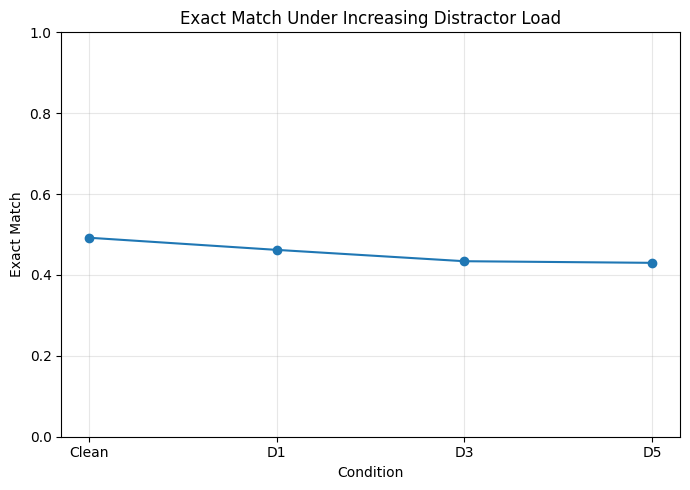

In [30]:
# Figure 1: EM by distractor count

conditions = ["Clean", "D1", "D3", "D5"]

values = [
    paired_dist["clean_em"].mean(),
    paired_dist["em_D1"].mean(),
    paired_dist["em_D3"].mean(),
    paired_dist["em_D5"].mean(),
]

plt.figure(figsize=(7, 5))
plt.plot(
    conditions,
    values,
    marker="o",
)

plt.xlabel("Condition")
plt.ylabel("Exact Match")
plt.title("Exact Match Under Increasing Distractor Load")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    OUT_DIR / "figure_distractor_em.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


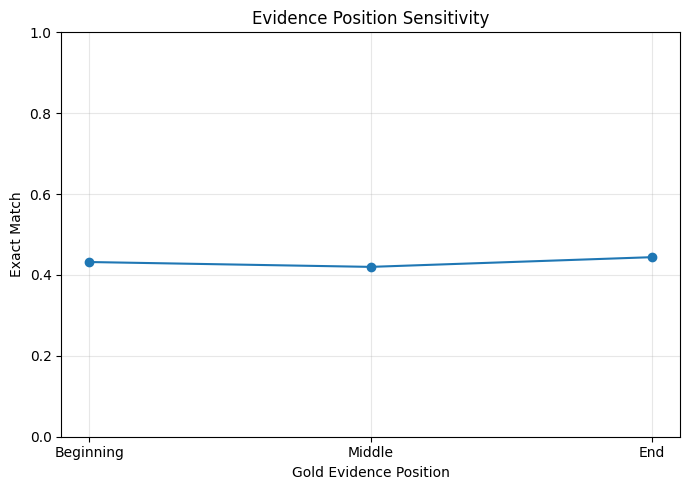

In [31]:
# Figure 2: Position EM

conditions = ["Beginning", "Middle", "End"]

values = [
    pos_wide["em_beginning"].mean(),
    pos_wide["em_middle"].mean(),
    pos_wide["em_end"].mean(),
]

plt.figure(figsize=(7, 5))
plt.plot(
    conditions,
    values,
    marker="o",
)

plt.xlabel("Gold Evidence Position")
plt.ylabel("Exact Match")
plt.title("Evidence Position Sensitivity")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    OUT_DIR / "figure_position_em.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


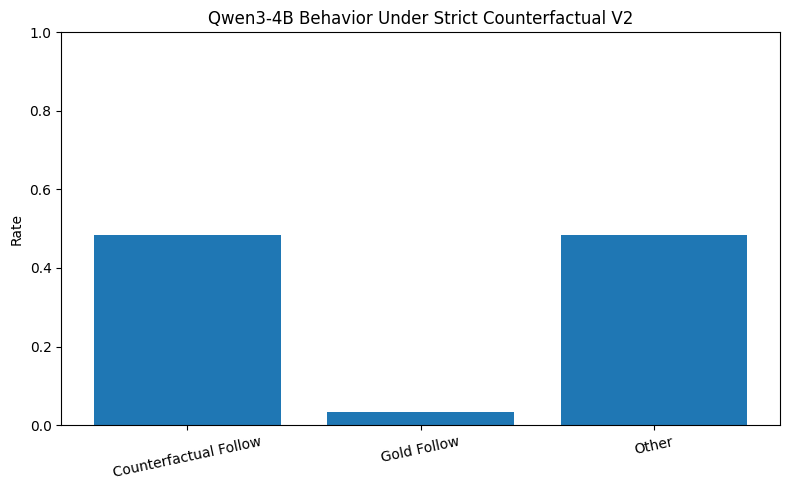

In [32]:
# Figure 3: Counterfactual behavior

labels = [
    "Counterfactual Follow",
    "Gold Follow",
    "Other",
]

values = [
    (
        cf_df["cf_class"]
        == "COUNTERFACTUAL_FOLLOW"
    ).mean(),
    (
        cf_df["cf_class"]
        == "GOLD_FOLLOW"
    ).mean(),
    (
        cf_df["cf_class"]
        == "OTHER"
    ).mean(),
]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)

plt.ylabel("Rate")
plt.title("Qwen3-4B Behavior Under Strict Counterfactual V2")
plt.ylim(0, 1)
plt.xticks(rotation=12)

plt.tight_layout()
plt.savefig(
    OUT_DIR / "figure_counterfactual_v2_behavior.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


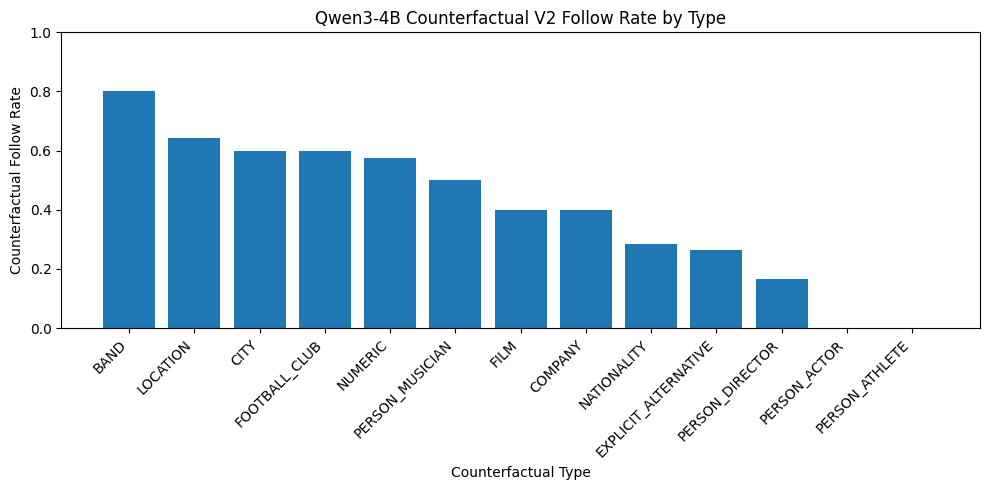

In [33]:
# Figure 4: CFR by counterfactual type
# Only types with at least 5 examples are shown for stability.

plot_df = (
    cf_by_type[
        cf_by_type["total"] >= 5
    ]
    .sort_values("CFR", ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    plot_df["counterfactual_type"],
    plot_df["CFR"],
)

plt.ylabel("Counterfactual Follow Rate")
plt.xlabel("Counterfactual Type")
plt.title("Qwen3-4B Counterfactual V2 Follow Rate by Type")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(
    OUT_DIR / "figure_counterfactual_v2_cfr_by_type.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# 26. Save all analysis tables


In [34]:
dist_stats_df.to_csv(
    OUT_DIR / "distractor_significance_tests.csv",
    index=False
)

position_stats_df.to_csv(
    OUT_DIR / "position_significance_tests.csv",
    index=False
)

trajectory_counts.to_csv(
    OUT_DIR / "distractor_trajectory_counts.csv",
    index=False
)

trajectory_class_summary.to_csv(
    OUT_DIR / "distractor_trajectory_classes.csv",
    index=False
)

transition_df.to_csv(
    OUT_DIR / "clean_correct_to_perturbed_wrong.csv",
    index=False
)

pos_trajectory_counts.to_csv(
    OUT_DIR / "position_trajectory_counts.csv",
    index=False
)

cf_summary.to_csv(
    OUT_DIR / "counterfactual_v2_behavior_summary.csv",
    index=False
)

cf_by_type.to_csv(
    OUT_DIR / "counterfactual_v2_by_type.csv"
)

cf_by_source.to_csv(
    OUT_DIR / "counterfactual_v2_by_replacement_source.csv"
)

print("Saved CSV analysis tables.")


Saved CSV analysis tables.


## 27. Save representative failure cases


In [35]:
d5_induced.to_csv(
    OUT_DIR / "examples_d5_induced_failures.csv",
    index=False
)

lost_middle_with_q.to_csv(
    OUT_DIR / "examples_lost_in_middle.csv",
    index=False
)

cf_df[
    cf_df["cf_class"] == "COUNTERFACTUAL_FOLLOW"
].to_csv(
    OUT_DIR / "examples_counterfactual_v2_follow.csv",
    index=False
)

cf_df[
    cf_df["cf_class"] == "GOLD_FOLLOW"
].to_csv(
    OUT_DIR / "examples_counterfactual_v2_gold_follow.csv",
    index=False
)

cf_df[
    cf_df["cf_class"] == "OTHER"
].to_csv(
    OUT_DIR / "examples_counterfactual_v2_other.csv",
    index=False
)

print("Saved qualitative example tables.")


Saved qualitative example tables.


# 28. Final machine-readable analysis summary


In [36]:
analysis_summary = {
    "model": MODEL_NAME,
    "analysis_version": ANALYSIS_VERSION,

    "n_clean": int(len(clean_df)),
    "n_distractor_rows": int(len(distractor_df)),
    "n_position_rows": int(len(position_df)),
    "n_counterfactual_v2": int(len(cf_df)),

    "distractor": {
        "clean_em":
            float(paired_dist["clean_em"].mean()),

        "D1_em":
            float(paired_dist["em_D1"].mean()),

        "D3_em":
            float(paired_dist["em_D3"].mean()),

        "D5_em":
            float(paired_dist["em_D5"].mean()),

        "clean_correct_n":
            int(len(clean_correct)),

        "clean_correct_to_D1_wrong_rate":
            float(
                transition_df.loc[
                    transition_df["condition"] == "D1",
                    "failure_rate_given_clean_correct"
                ].iloc[0]
            ),

        "clean_correct_to_D3_wrong_rate":
            float(
                transition_df.loc[
                    transition_df["condition"] == "D3",
                    "failure_rate_given_clean_correct"
                ].iloc[0]
            ),

        "clean_correct_to_D5_wrong_rate":
            float(
                transition_df.loc[
                    transition_df["condition"] == "D5",
                    "failure_rate_given_clean_correct"
                ].iloc[0]
            ),
    },

    "position": {
        "beginning_em":
            float(pos_wide["em_beginning"].mean()),

        "middle_em":
            float(pos_wide["em_middle"].mean()),

        "end_em":
            float(pos_wide["em_end"].mean()),

        "strict_lost_middle_count":
            int(len(lost_middle)),

        "strict_lost_middle_rate":
            float(lost_middle_rate),

        "middle_fail_given_edge_success":
            float(middle_fail_given_edge_success),
    },

    "counterfactual_v2": {
        "n":
            int(len(cf_df)),

        "CFR":
            float(
                (
                    cf_df["cf_class"]
                    == "COUNTERFACTUAL_FOLLOW"
                ).mean()
            ),

        "GFR":
            float(
                (
                    cf_df["cf_class"]
                    == "GOLD_FOLLOW"
                ).mean()
            ),

        "OTHER_rate":
            float(
                (
                    cf_df["cf_class"]
                    == "OTHER"
                ).mean()
            ),
    },
}

SUMMARY_PATH = (
    OUT_DIR
    / "qwen3_4b_statistical_analysis_counterfactual_v2.json"
)

with SUMMARY_PATH.open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        analysis_summary,
        f,
        indent=2
    )

print(
    json.dumps(
        analysis_summary,
        indent=2
    )
)

print("\nSaved:", SUMMARY_PATH)


{
  "model": "Qwen/Qwen3-4B-Instruct-2507",
  "analysis_version": "counterfactual_v2",
  "n_clean": 500,
  "n_distractor_rows": 1500,
  "n_position_rows": 1500,
  "n_counterfactual_v2": 232,
  "distractor": {
    "clean_em": 0.492,
    "D1_em": 0.462,
    "D3_em": 0.434,
    "D5_em": 0.43,
    "clean_correct_n": 246,
    "clean_correct_to_D1_wrong_rate": 0.09349593495934959,
    "clean_correct_to_D3_wrong_rate": 0.15853658536585366,
    "clean_correct_to_D5_wrong_rate": 0.16260162601626016
  },
  "position": {
    "beginning_em": 0.432,
    "middle_em": 0.42,
    "end_em": 0.444,
    "strict_lost_middle_count": 7,
    "strict_lost_middle_rate": 0.014,
    "middle_fail_given_edge_success": 0.15163934426229508
  },
  "counterfactual_v2": {
    "n": 232,
    "CFR": 0.4827586206896552,
    "GFR": 0.034482758620689655,
    "OTHER_rate": 0.4827586206896552
  }
}

Saved: /content/drive/MyDrive/rag_stress/analysis_qwen3_4b_counterfactual_v2/qwen3_4b_statistical_analysis_counterfactual_v2.json


# Interpretation checklist

Use the results to answer these research questions:

### RQ1 — Distractor robustness
Does performance significantly degrade as semantically related distractors increase from D1 → D3 → D5?

Look at:
- EM/F1 trend
- paired bootstrap CIs
- McNemar p-values
- Wilcoxon F1 p-values
- clean-correct → perturbed-wrong transitions

### RQ2 — Position sensitivity
Does moving the same gold evidence block change performance?

Look at:
- Beginning vs Middle vs End
- paired significance tests
- `1 → 0 → 1` lost-in-the-middle cases

### RQ3 — Counterfactual susceptibility
When retrieved context contains an injected false claim, does the model follow the context or preserve the original answer?

Look at:
- CFR
- GFR
- OTHER rate
- CFR by answer type
- CFR by replacement source

### RQ4 — Failure structure
Are failures monotonic as perturbation severity increases, or are they unstable/non-monotonic?

Look at:
- distractor trajectories
- `ROBUST_ALL`
- `FAILS_AT_D1`
- `FAILS_AT_D3`
- `FAILS_AT_D5`
- `NON_MONOTONIC_DEGRADATION`
- `PERTURBATION_RECOVERY`

These analyses are substantially stronger than reporting only aggregate accuracy.


## Final Google Drive analysis manifest

In [37]:
print("Analysis saved under:")
print(OUT_DIR)

print("\nGenerated files:")
for path in sorted(OUT_DIR.glob("*")):
    print("-", path.name)

print("\nThis analysis uses:")
print("  Clean / Distractor / Position -> previous Qwen3-4B evaluated outputs")
print("  Counterfactual              -> strict semantic Counterfactual V2")


Analysis saved under:
/content/drive/MyDrive/rag_stress/analysis_qwen3_4b_counterfactual_v2

Generated files:
- clean_correct_to_perturbed_wrong.csv
- counterfactual_v2_behavior_summary.csv
- counterfactual_v2_by_replacement_source.csv
- counterfactual_v2_by_type.csv
- distractor_significance_tests.csv
- distractor_trajectory_classes.csv
- distractor_trajectory_counts.csv
- examples_counterfactual_v2_follow.csv
- examples_counterfactual_v2_gold_follow.csv
- examples_counterfactual_v2_other.csv
- examples_d5_induced_failures.csv
- examples_lost_in_middle.csv
- figure_counterfactual_v2_behavior.png
- figure_counterfactual_v2_cfr_by_type.png
- figure_distractor_em.png
- figure_position_em.png
- position_significance_tests.csv
- position_trajectory_counts.csv
- qwen3_4b_statistical_analysis_counterfactual_v2.json

This analysis uses:
  Clean / Distractor / Position -> previous Qwen3-4B evaluated outputs
  Counterfactual              -> strict semantic Counterfactual V2
